# Machine Learning training notebook
This notebook automates the following processes:
- Downloading the `puneet6060/intel-image-classification` Kaggle dataset to `./dataset` 
- Runs the EDA and preprocessing 
- Runs the traditional training pipeline **<-- (currently here)**
- Runs the modern training pipeline

In [1]:
# Make sure you have all the requirements installed
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import random
from pathlib import Path

import imagehash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image, ImageStat

from helper.dataset_helper import zip_extraction, save_clean_dataset_and_metadata, load_dataset_from_directories
from helper.eda_helper import build_master_dataframe, clean_dataset

## Phase 1: EDA and Preprocessing

In [3]:
# Download
os.makedirs("dataset", exist_ok=True)
!kaggle datasets download -d puneet6060/intel-image-classification -p ./dataset

# Extract Dataset
project_root = Path.cwd()
dataset_info = zip_extraction(project_root)

if dataset_info is None:
    print("Failed to fetch or extract dataset info.")
else:
    print("Dataset ready.")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
[INFO] Dataset is already extracted, flattened, and split. Skipping re-extraction.
Dataset ready.
[INFO] Dataset is already extracted, flattened, and split. Skipping re-extraction.
Dataset ready.


In [4]:
df = build_master_dataframe(dataset_info)

display(df.head())
print("Master DataFrame built. Disk I/O is finished.")

Extracting metrics for 17034 images.


,filepath,split,class,filename,width,height,channels,dtype,file_bytes,phash,mean_r,mean_g,mean_b,std_r,std_g,std_b
0,/home/banana9205/Desktop/Main/Uni/ML/ML_IMAGE_...,test,forest,23116.jpg,150,150,3,uint8,22099,cece3df5900a6ae0,132.009556,98.384178,95.438578,50.200373,57.139180,68.948545
1,/home/banana9205/Desktop/Main/Uni/ML/ML_IMAGE_...,test,forest,21187.jpg,150,150,3,uint8,16542,c7873e30b4ac989b,47.440311,47.440311,47.440311,62.007213,62.007213,62.007213
2,/home/banana9205/Desktop/Main/Uni/ML/ML_IMAGE_...,test,forest,22626.jpg,150,150,3,uint8,20763,db889cc4e7723439,99.383822,88.216889,82.643289,53.837329,52.861181,50.602363
3,/home/banana9205/Desktop/Main/Uni/ML/ML_IMAGE_...,test,forest,23053.jpg,150,150,3,uint8,21321,86f5d9375923d109,74.331867,80.884089,56.494889,45.810295,47.060411,44.343644
4,/home/banana9205/Desktop/Main/Uni/ML/ML_IMAGE_...,test,forest,20785.jpg,150,150,3,uint8,22598,91adc0e631e633c7,68.157867,107.854622,63.168311,48.982275,52.059875,47.505578


Master DataFrame built. Disk I/O is finished.


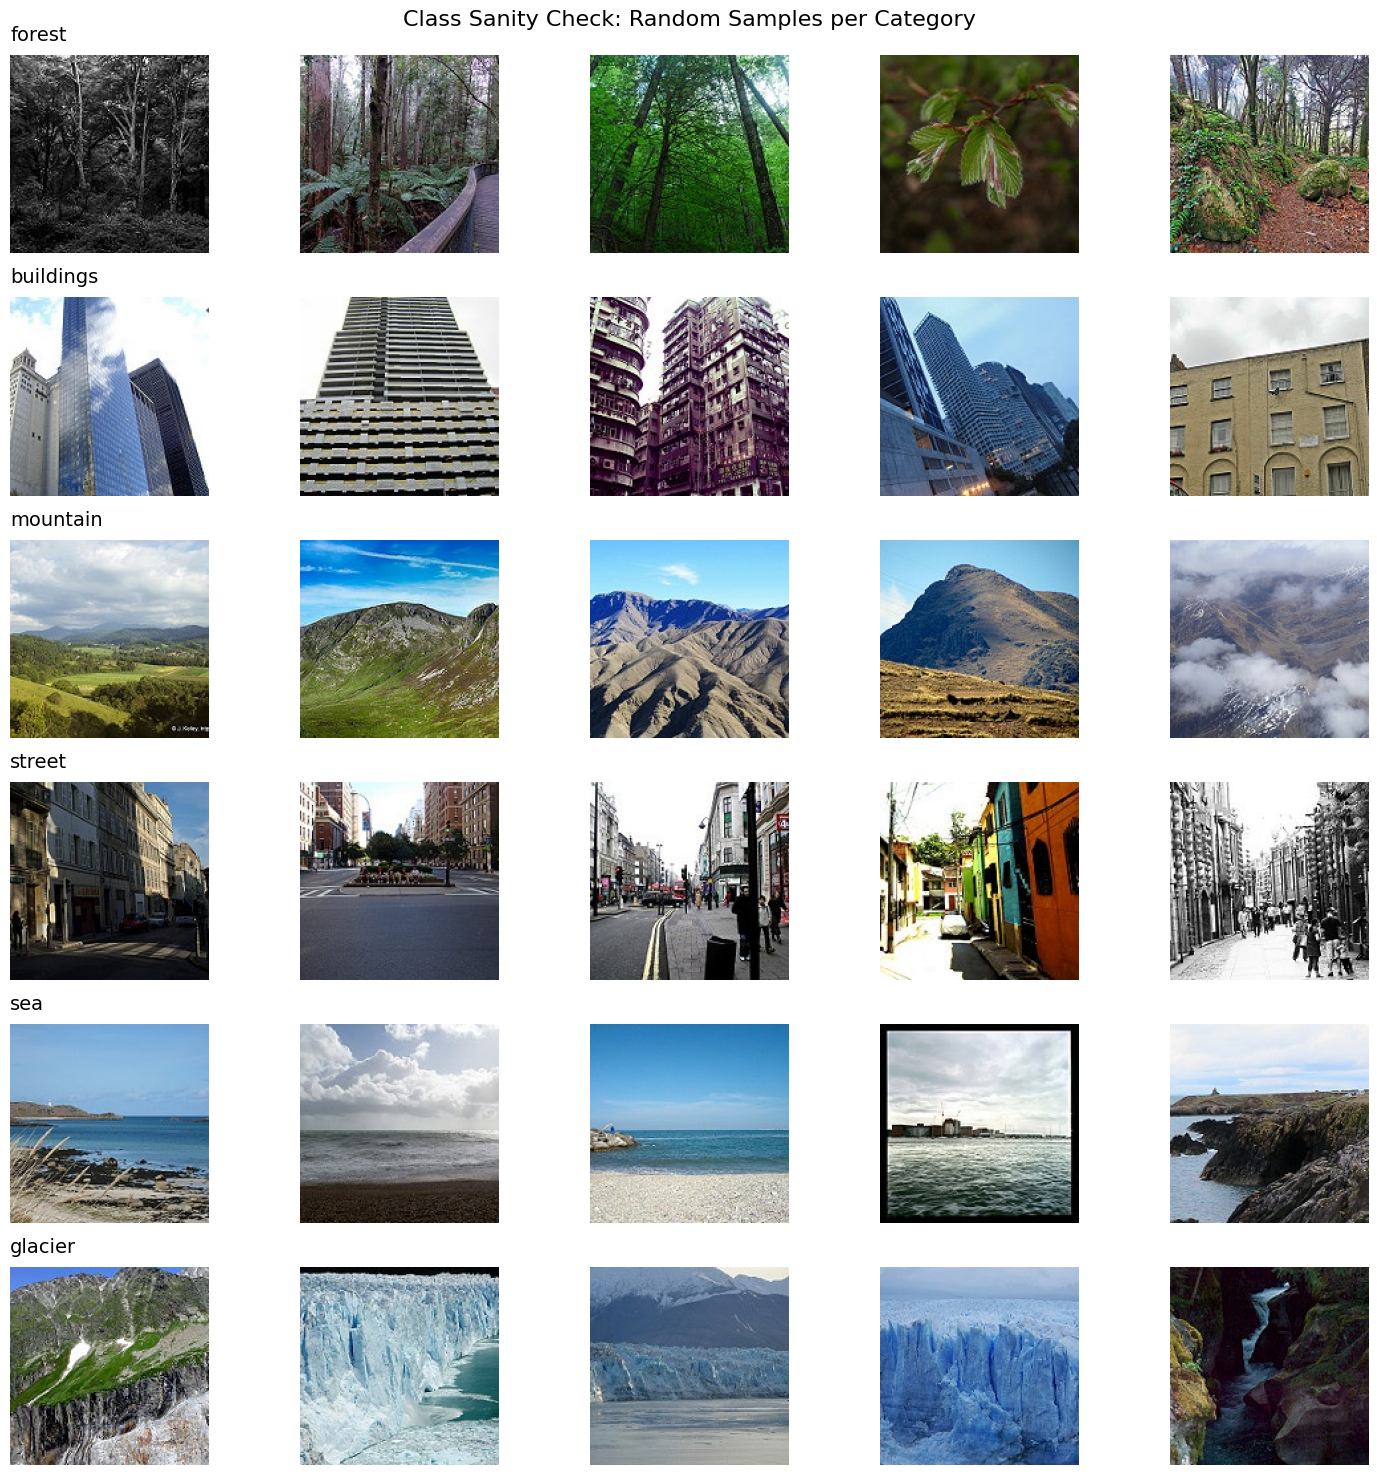

In [5]:
# Filter out corrupted files before sampling
valid_classes = df[df['class'] != 'Unknown']['class'].unique()

fig, axes = plt.subplots(len(valid_classes), 5, figsize=(15, 2.5 * len(valid_classes)))
fig.suptitle("Class Sanity Check: Random Samples per Category", fontsize=16)

for idx, cls in enumerate(valid_classes):
    # Grab 5 random filepaths for this specific class
    class_files = df[(df['class'] == cls) & (df['file_bytes'] > 0)]['filepath'].tolist()
    sample_files = random.sample(class_files, min(5, len(class_files)))
    
    for col_idx, img_path in enumerate(sample_files):
        ax = axes[idx, col_idx]
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(cls, fontsize=14, loc='left', pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

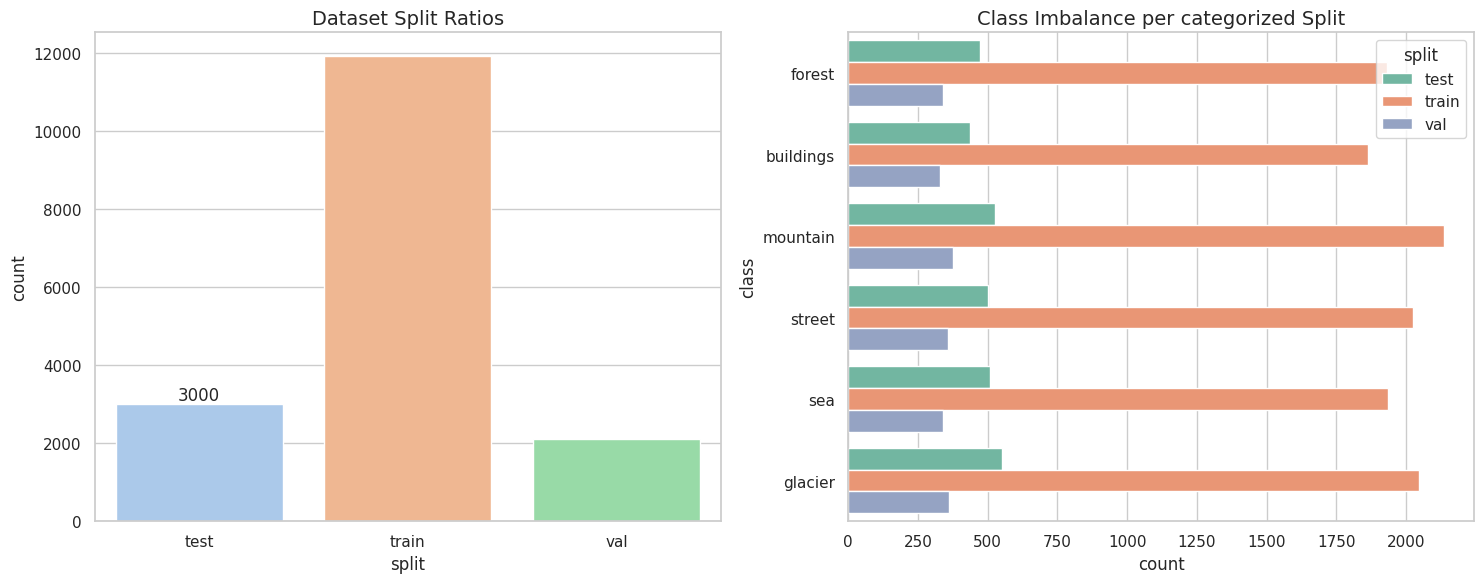

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall Split Distribution
sns.countplot(data=df, x='split', hue='split', ax=axes[0], palette="pastel", legend=False)
axes[0].set_title("Dataset Split Ratios", fontsize=14)
axes[0].bar_label(axes[0].containers[0])

# Class Breakdown inside Train/Val/Test
classified_df = df[df['class'] != 'Unknown']
sns.countplot(data=classified_df, y='class', hue='split', ax=axes[1], palette="Set2")
axes[1].set_title("Class Imbalance per categorized Split", fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
# 1. Empty or corrupted files
empty_files = df[df['file_bytes'] == 0]
unreadable = df[(df['width'].isna()) & (df['file_bytes'] > 0)]
print(f"Empty files (0 bytes): {len(empty_files)}")
print(f"Unreadable/Corrupted files: {len(unreadable)}")

# 2. File Extension Distribution
df['extension'] = df['filename'].str.lower().str.extract(r'(\.[^.]+)$', expand=False)
invalid_extensions = df[~df['extension'].isin({".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp"})]

print(f"Non-image formats detected: {len(invalid_extensions)}")
display(df['extension'].value_counts().to_frame(name="Count"))

Empty files (0 bytes): 0
Unreadable/Corrupted files: 0
Non-image formats detected: 0


,Count
extension,
.jpg,17034


In [8]:
clean_df = clean_dataset(df)

Original dataset size: 17034

Total Valid Images: 17034
Images at exactly 150x150: 16979 (99.68%)
Total Non-Square Images Detected: 55

Class Breakdown Summary:


,150x150 Count,Outlier Count
class,,
mountain,3018,19
glacier,2936,21
street,2882,1
sea,2780,4
forest,2736,9
buildings,2627,1


-> Removed 55 invalid, unknown, or non-square images.

Detected 51 redundant duplicate copies in the dataset.
Cross-Split Leakage (Images appearing in multiple splits):


split,test,train,val
phash,,,
820f4f43f7f6c181,1,1,0
84e4fa9e8cc2e1f2,0,2,0
85f67904e6799562,0,2,0
86c468be37111fce,0,2,0
86c6b918c6c7f531,0,1,1
86ceed6939861617,0,1,1
87a92e54972b4e95,0,2,0
87ba50679f15aac1,1,1,0
87e01fe25f01d44f,0,2,0


-> Removed 51 redundant images (Prioritized keeping test/val instances).

Final Cleaned Dataset Size: 16928



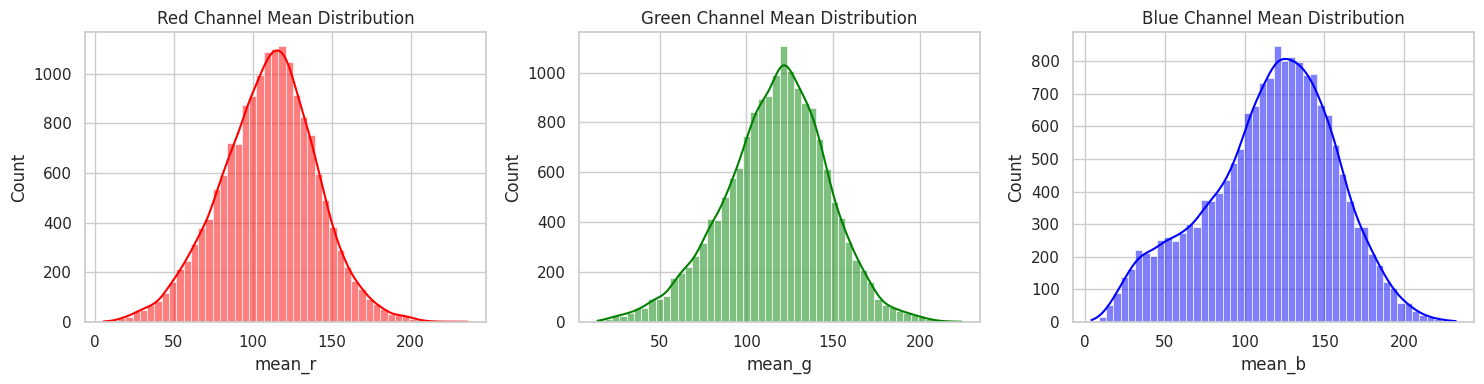


Recommended Dataset Normalization Metrics (0.0-1.0 scale)
Mean => R: 0.4309 | G: 0.4577 | B: 0.4542
Std  => R: 0.2358 | G: 0.2347 | B: 0.2431


In [9]:
# Ensure we use the mathematically pure dataset from the previous step
final_stats = clean_df.dropna(subset=['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']).copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(final_stats['mean_r'], bins=50, ax=axes[0], color='red', kde=True)
axes[0].set_title("Red Channel Mean Distribution")

sns.histplot(final_stats['mean_g'], bins=50, ax=axes[1], color='green', kde=True)
axes[1].set_title("Green Channel Mean Distribution")

sns.histplot(final_stats['mean_b'], bins=50, ax=axes[2], color='blue', kde=True)
axes[2].set_title("Blue Channel Mean Distribution")

plt.tight_layout()
plt.show()

norm_mean_r = final_stats['mean_r'].mean() / 255.0
norm_mean_g = final_stats['mean_g'].mean() / 255.0
norm_mean_b = final_stats['mean_b'].mean() / 255.0

norm_std_r = final_stats['std_r'].mean() / 255.0
norm_std_g = final_stats['std_g'].mean() / 255.0
norm_std_b = final_stats['std_b'].mean() / 255.0

# Print global dataset means / stds useful for PyTorch/TensorFlow preprocessing configs
print("\nRecommended Dataset Normalization Metrics (0.0-1.0 scale)")
print(f"Mean => R: {norm_mean_r:.4f} | G: {norm_mean_g:.4f} | B: {norm_mean_b:.4f}")
print(f"Std  => R: {norm_std_r:.4f} | G: {norm_std_g:.4f} | B: {norm_std_b:.4f}")

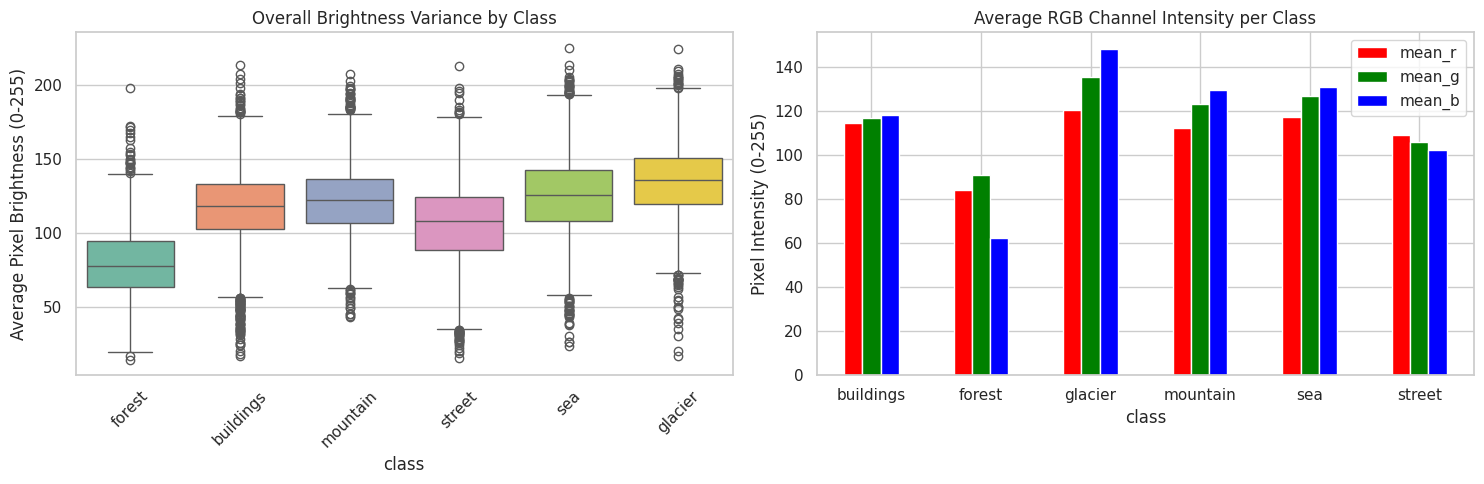

In [10]:
# Calculate perceived overall brightness as a simple average of the RGB channels
final_stats['brightness'] = final_stats[['mean_r', 'mean_g', 'mean_b']].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Overall Brightness Variance
sns.boxplot(data=final_stats, x='class', y='brightness', hue='class', ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Overall Brightness Variance by Class")
axes[0].set_ylabel("Average Pixel Brightness (0-255)")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: RGB Means by Class
class_rgb_means = final_stats.groupby('class')[['mean_r', 'mean_g', 'mean_b']].mean()
class_rgb_means.plot(kind='bar', color=['red', 'green', 'blue'], ax=axes[1])
axes[1].set_title("Average RGB Channel Intensity per Class")
axes[1].set_ylabel("Pixel Intensity (0-255)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
save_clean_dataset_and_metadata(clean_df, project_root, norm_mean_r, norm_mean_g, norm_mean_b, norm_std_r, norm_std_g, norm_std_b)

Metadata (with split paths) successfully saved to /home/banana9205/Desktop/Main/Uni/ML/ML_IMAGE_DATASET/dataset_metadata.json


## Phase 2: Traditional Pipeline

In [12]:
from helper.traditional_helper import BasePreprocessor, HOGPreprocessor, SIFTPreprocessor, run_traditional_pipeline

# Ensure we load the clean, correctly structured dataset from Phase 1
clean_dl_df = load_dataset_from_directories(project_root)
print(f"Loaded dataset for phase 2. Size: {len(clean_dl_df)}")

Loaded dataset with 17034 images.
Loaded dataset for phase 2. Size: 17034


In [13]:
# ~6m runtime
# Evaluate with vocab_size = 400
results_400_df, preds_400_dict, class_names_400 = run_traditional_pipeline(
    df=clean_dl_df,
    vocab_size=400,
    feature_configs=['hog', 'sift'],
    max_sift_samples=1500,
    pca_components=500,
    show_report=True
)

print("\n" + "="*50)
print("       FINAL MODEL COMPARISON (Vocab=400)")
print("="*50)
print(results_400_df.to_string(index=False))


 FEATURE EXTRACTION: HOG 
Extracting features for train split (11932 images)...
Extracting features for test split (3000 images)...
Extracting features for test split (3000 images)...
Applying PCA (n_components=500) to HOG...
Applying PCA (n_components=500) to HOG...
-> Running HOG + SVM...
-> Running HOG + SVM...
Detailed Report for HOG + SVM:
              precision    recall  f1-score   support

   buildings       0.74      0.69      0.72       437
      forest       0.83      0.94      0.88       474
     glacier       0.57      0.54      0.56       553
    mountain       0.51      0.55      0.53       525
         sea       0.67      0.63      0.65       510
      street       0.79      0.76      0.77       501

    accuracy                           0.68      3000
   macro avg       0.68      0.69      0.68      3000
weighted avg       0.68      0.68      0.68      3000

-> Running HOG + LR...
Detailed Report for HOG + SVM:
              precision    recall  f1-score   support



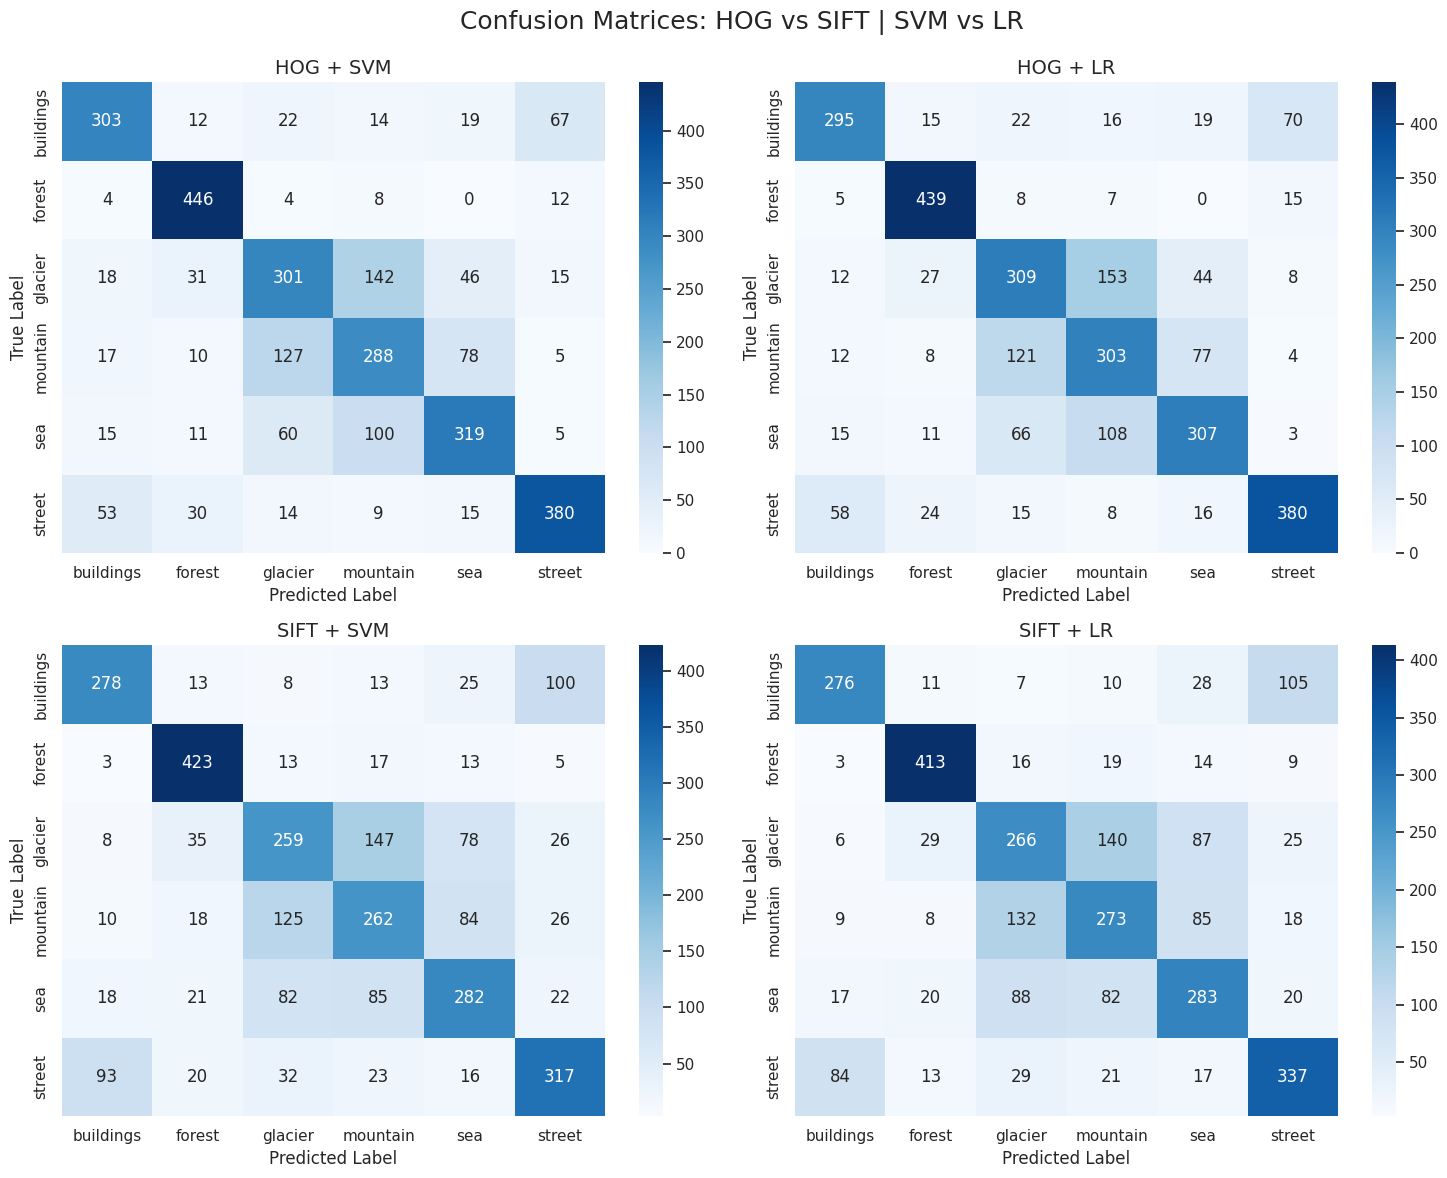

In [14]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

fig.suptitle("Confusion Matrices: HOG vs SIFT | SVM vs LR", fontsize=18)

for idx, (exp_name, (y_test_true, y_pred_model)) in enumerate(preds_400_dict.items()):
    if idx >= 4:
        break # Just in case
    cm = confusion_matrix(y_test_true, y_pred_model)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names_400, yticklabels=class_names_400)
    axes[idx].set_title(f"{exp_name}", fontsize=14)
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()